<a href="https://colab.research.google.com/github/Veritax0/BEV-vs-ICE/blob/main/sesiones_practicas/sp_4_Juan_Manuel_Vera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

Relacione sus datos y los del compañero de trabajo

Juan Manuel Vera Osorio CC. 1000416823

# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

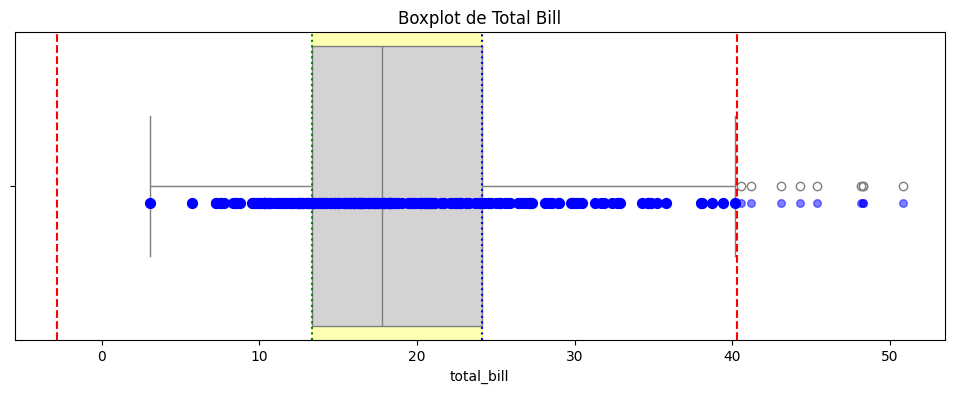

In [82]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]

Q1 = tips["total_bill"].quantile(0.25)
Q3 = tips["total_bill"].quantile(0.75)
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR
tips['outlier_iqr'] = (tips["total_bill"] < lim_inf) | (tips["total_bill"] > lim_sup)

plt.figure(figsize=(12,4))
plt.title("Boxplot de Total Bill")
plt.xlabel("total_bill")
sns.boxplot(x=total_bill, color="lightgray")
plt.axvspan(Q1, Q3, color='yellow', alpha=0.3, label='Rango IQR')
plt.axvline(Q1, color='green', linestyle=':', label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='blue', linestyle=':', label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf, color='red', linestyle='--', label=f'Límite inferior = {lim_inf:.2f}')
plt.axvline(lim_sup, color='red', linestyle='--', label=f'Límite superior = {lim_sup:.2f}')
plt.scatter(data_a, [0.05]*len(data_a), color="blue", s=30, alpha=0.5)
plt.scatter(data_b, [0.05]*len(data_b), color="blue", s=50, zorder=5)
plt.show()


La gráfica presenta varios valores que se alejan del rango intercuartil hacia arriba, lo que indica varios valores que podrían considerarse atipicos por encima de 40, sin embargo, como estamos hablando de facturas, podría considerarse variabilidad naturarl, algunos casos particulares en las que las personas tienen un mayor consumo que lleva a un mayor valor facturado

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

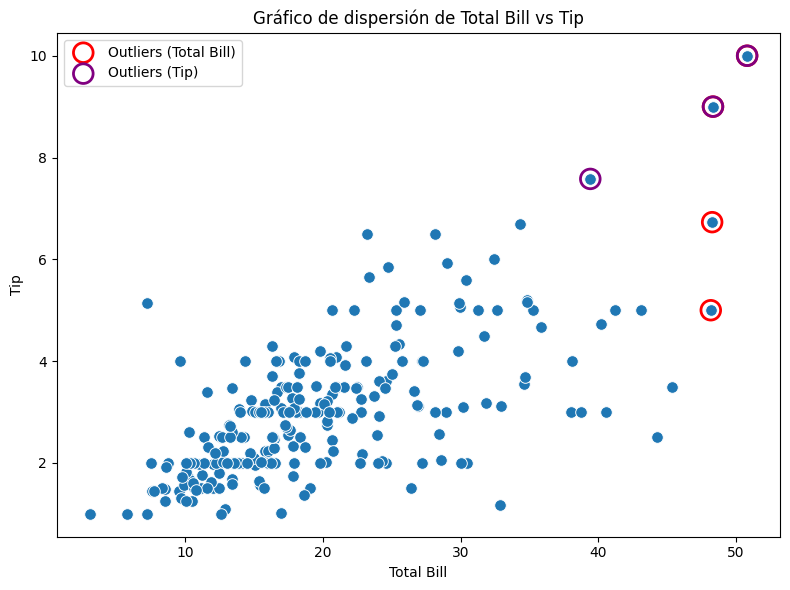

In [83]:
from matplotlib.colors import Colormap
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore # Import zscore

tips = sns.load_dataset("tips")

x = tips["total_bill"].values
y = tips["tip"].values
# Calcular Z score
tips['z_score_bill'] = zscore(tips['total_bill'])

# Calcular Z score
tips['z_score_tips'] = zscore(tips['tip'])
condiciones = [(tips['z_score_bill'].abs() > 3), (tips['z_score_tips'].abs() > 3)]
choices = ["Bill", "Tips"]
tips['outlier_z_bill'] = tips['z_score_bill'].abs() > 3
tips['outlier_z_tips'] = tips['z_score_tips'].abs() > 3


# Media y desviación estándar global
mu = tips['tip'].mean()
sigma = tips['tip'].std(ddof=0)

# Calcular z-score
tips['z_score1'] = (tips['tip'] - mu) / sigma


plt.figure(figsize=(8,6))
plt.title("Gráfico de dispersión de Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
sns.scatterplot(x=x, y=y, s=70,)

# Identify outliers based on z-score for total_bill
outlier_mask_bill = tips['z_score_bill'].abs() > 3
outlier_x_bill = tips['total_bill'][outlier_mask_bill]
outlier_y_bill = tips['tip'][outlier_mask_bill]

# Identify outliers based on z-score for tip
outlier_mask_tip = tips['z_score_tips'].abs() > 3
outlier_x_tip = tips['total_bill'][outlier_mask_tip]
outlier_y_tip = tips['tip'][outlier_mask_tip]

# Plot outliers for total_bill
plt.scatter(outlier_x_bill, outlier_y_bill,
            s=200,                # Tamaño del círculo (más grande)
            facecolors='none',    # Sin relleno
            edgecolors='red',     # Color del borde
            linewidths=2,         # Grosor del borde
            label='Outliers (Total Bill)')

# Plot outliers for tip
plt.scatter(outlier_x_tip, outlier_y_tip,
            s=200,                # Tamaño del círculo (más grande)
            facecolors='none',    # Sin relleno
            edgecolors='purple',  # Color del borde
            linewidths=2,         # Grosor del borde
            label='Outliers (Tip)')

plt.legend()
plt.tight_layout()
plt.show()

Aquí se puede observar una tendencia lineal en los datos, las facturas más grandes suelen aportar una propina mayor, se pueden observar los datos atípicos de cada variable, para ambas se pude observar que usando el z-score, se marcan como posibles atipicos los datos más alejados de la tendencia, en este caso, tanto para las propinas como para los valores facturados se marcan los valores más altos, es posible que sea debido a la baja frecuencia con la que se cobran facturas demasiado altas. A diferencia del metodo de rango intercuartil, este metodo es menos sensible a los valores que se desvian moderadamente de la tendencia.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

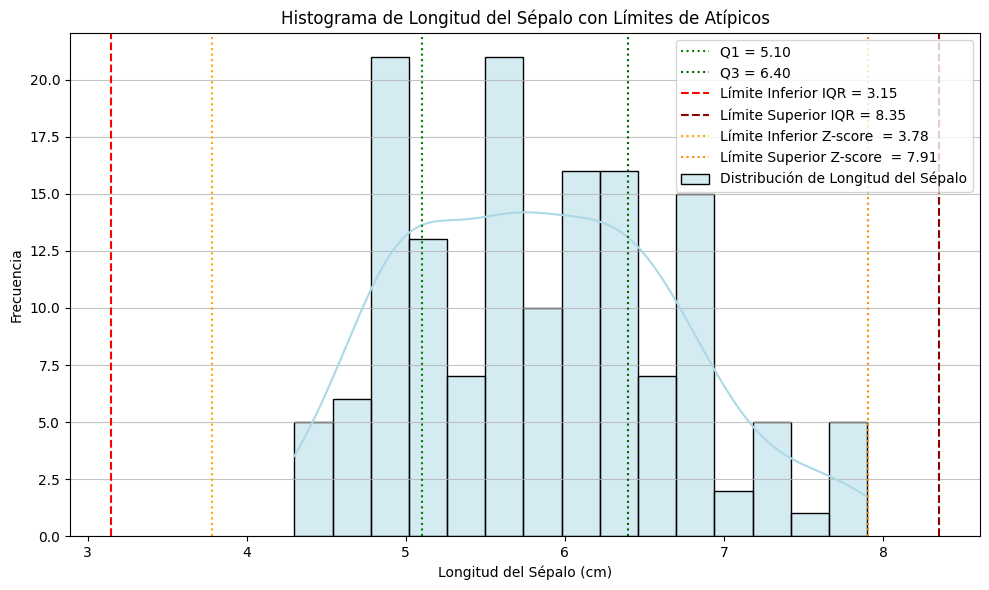

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore # Import zscore

iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

# Calculate IQR-based limits
Q1, Q3 = np.percentile(x, [25, 75])
IQR = Q3 - Q1
lim_inf_iqr = Q1 - 1.5 * IQR
lim_sup_iqr = Q3 + 1.5 * IQR

# Calculate Z-score based limits
mean_x = np.mean(x)
std_x = np.std(x)
lim_inf_z = mean_x - 2.5 * std_x
lim_sup_z = mean_x + 2.5 * std_x

plt.figure(figsize=(10,6))
plt.title("Histograma de Longitud del Sépalo con Límites de Atípicos")
plt.xlabel("Longitud del Sépalo (cm)")
plt.ylabel("Frecuencia")

# Plot histogram with KDE
sns.histplot(x=x, bins=15, kde=True, color="lightblue", label='Distribución de Longitud del Sépalo')

# Add IQR lines
plt.axvline(Q1, color='green', linestyle=':', linewidth=1.5, label=f'Q1 = {Q1:.2f}')
plt.axvline(Q3, color='darkgreen', linestyle=':', linewidth=1.5, label=f'Q3 = {Q3:.2f}')
plt.axvline(lim_inf_iqr, color='red', linestyle='--', linewidth=1.5, label=f'Límite Inferior IQR = {lim_inf_iqr:.2f}')
plt.axvline(lim_sup_iqr, color='darkred', linestyle='--', linewidth=1.5, label=f'Límite Superior IQR = {lim_sup_iqr:.2f}')

# Add Z-score lines
plt.axvline(lim_inf_z, color='orange', linestyle=':', linewidth=1.5, label=f'Límite Inferior Z-score  = {lim_inf_z:.2f}')
plt.axvline(lim_sup_z, color='darkorange', linestyle=':', linewidth=1.5, label=f'Límite Superior Z-score  = {lim_sup_z:.2f}')

plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

En este caso, con ambos metodos obtuvimos un limite similar, y en ambos no se considera ningun valor como atipico, si se identifica que el rango intecuartil es más rigido, en este caso podemos considerar ambos valores, y marcar todos los datos que se alejen más allá del limite IQR como atípicos

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

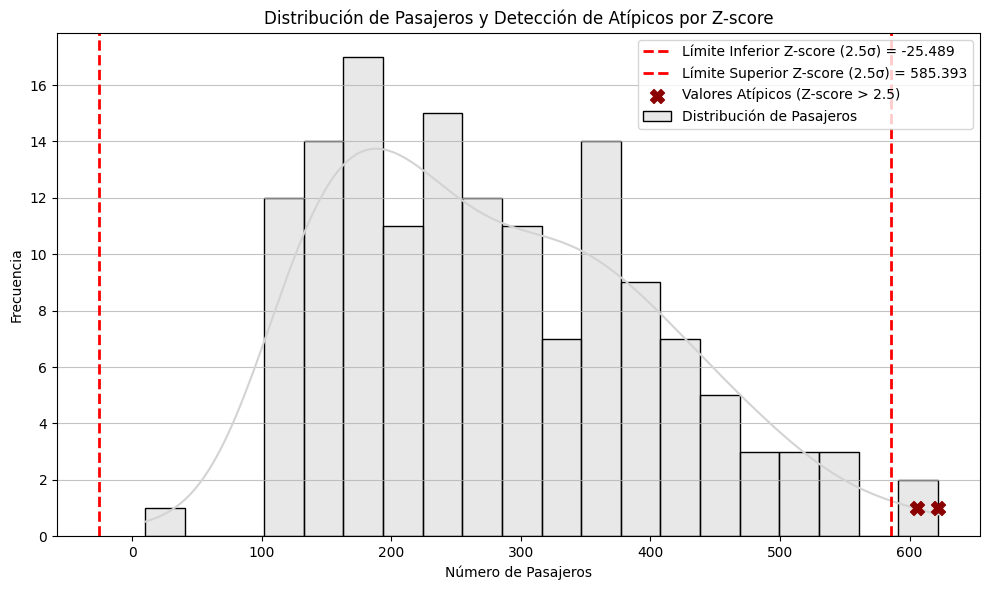

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500])

z_scores = zscore(x)
outlier_mask = np.abs(z_scores) > 2.5

# Calculate mean and standard deviation for Z-score thresholds
mean_x = np.mean(x)
std_x = np.std(x)
lim_inf_z = mean_x - 2.5 * std_x
lim_sup_z = mean_x + 2.5 * std_x

plt.figure(figsize=(10,6))
plt.title("Distribución de Pasajeros y Detección de Atípicos por Z-score")
plt.xlabel("Número de Pasajeros")
plt.ylabel("Frecuencia")

# Plot histogram with KDE
sns.histplot(x=x, bins=20, kde=True, color="lightgray", label='Distribución de Pasajeros')

# Add vertical lines for Z-score thresholds
plt.axvline(lim_inf_z, color='red', linestyle='--', linewidth=2, label=f'Límite Inferior Z-score (2.5σ) = {lim_inf_z:.3f}')
plt.axvline(lim_sup_z, color='red', linestyle='--', linewidth=2, label=f'Límite Superior Z-score (2.5σ) = {lim_sup_z:.3f}')

# Plot actual outlier points, making them visible and adding a label
plt.scatter(x[outlier_mask], np.full_like(x[outlier_mask], 1),
            color="darkred", s=100, marker="X", label="Valores Atípicos (Z-score > 2.5)", zorder=5)

plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

Al utilizar el metodo de z-score para determinar limites a 2 desviaciones estandar de la media, observamos que se marcan como valores atipicos los vuelos con muchos pasajeros, pues se registran 2 observaciones de 600 pasajeros al final de la cola derecha, ambos son casos extraños que podrían ser errores de medición, pues 600 pasajeros es una situacion poco común en un vuelo comercial

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

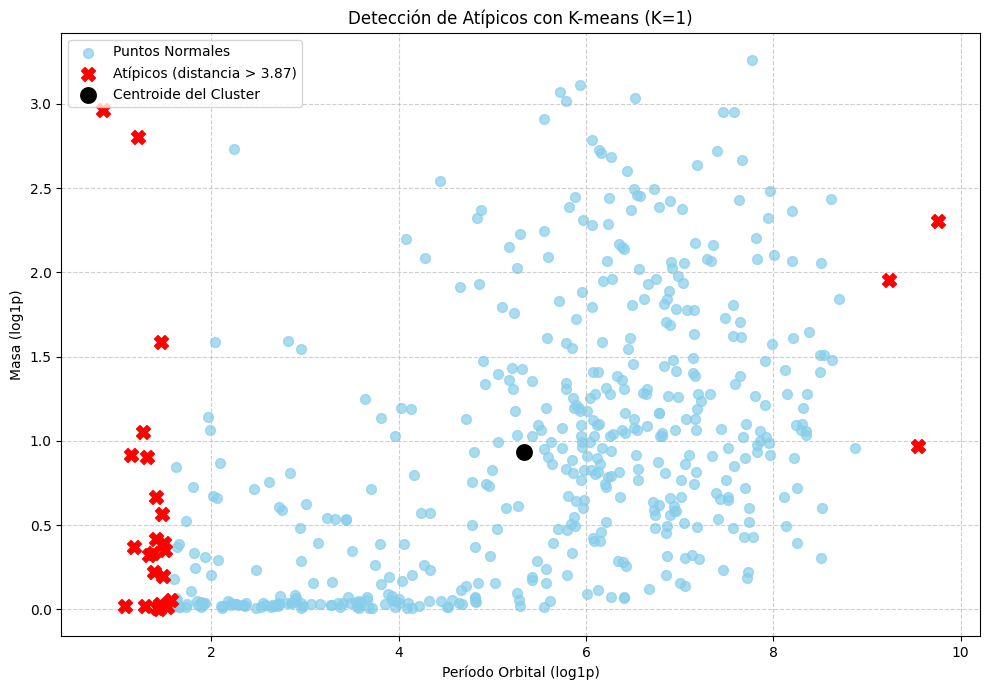

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X) # Apply log1p transformation as done previously


kmeans = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X)
labels = kmeans.labels_
centroid = kmeans.cluster_centers_[0]

# Calculate distances from each point to the centroid
distances = np.linalg.norm(X - centroid, axis=1)


outlier_threshold = np.percentile(distances, 95) # Top 5% furthest points as outliers

# Create a mask for outliers
outliers_mask = distances > outlier_threshold

plt.figure(figsize=(10, 7))
plt.title("Detección de Atípicos con K-means (K=1)")
plt.xlabel("Período Orbital (log1p)")
plt.ylabel("Masa (log1p)")

# Plot non-outliers
plt.scatter(X[~outliers_mask, 0], X[~outliers_mask, 1],
            c='skyblue', s=50, label='Puntos Normales', alpha=0.7)

# Plot outliers
plt.scatter(X[outliers_mask, 0], X[outliers_mask, 1],
            c='red', s=100, marker='X', label=f'Atípicos (distancia > {outlier_threshold:.2f})', zorder=5)

# Plot the centroid
plt.scatter(centroid[0], centroid[1],
            c='black', s=200, marker='o', label='Centroide del Cluster', edgecolors='white', linewidth=2, zorder=6)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()